##### ARTI 560 - Computer Vision

## Object Detection Using YOLOV8 with KerasCV - Exercise

### Objective

In this exercise, you wil learn how to use the pre-trained YOLOV8 model from KerasCV to detect objects in images.

You will:

1. Load the pre-trained YOLOV8 model from KerasCV using the [Pascal VOC preset](https://www.kaggle.com/models/keras/yolov8)

2. Load 5 images for different classes in [Pascal VOC 2012 dataset](https://datasetninja.com/pascal-voc-2012) and convert it into a NumPy array suitable for the model.

3. Resize the images before inference to match the model’s expected input size using:
    ```
    inference_resizing = keras_cv.layers.Resizing(
        640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
    )
    ```

    **Note:** Resizing ensures that the images fit the model input, maintains aspect ratio, and correctly adjusts bounding boxes.

4. Run the YOLOV8 detector on each image to predict bounding boxes, class labels, and confidence scores.

5. Visualize the predictions by drawing the bounding boxes and labels on the images.

6. Record for each image:

    - Which objects were detected correctly

    - The confidence scores of the detections

    - Any missed or incorrectly labeled objects

In [3]:
!pip install -q keras-cv tensorflow pillow matplotlib pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 650.7/650.7 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 950.8/950.8 kB 32.6 MB/s eta 0:00:00


=> Loading YOLOv8 Pascal VOC model...
=> Initializing the required Resizing Layer...

----------------------------------------
Analyzing image: Sheep
----------------------------------------
Detected Objects Summary:
- sheep: 69.97% confidence


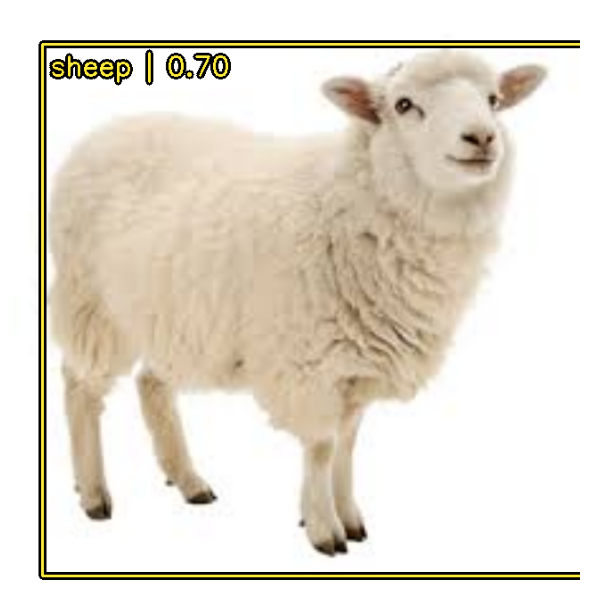


----------------------------------------
Analyzing image: Bus
----------------------------------------
Detected Objects Summary:
- bus: 98.58% confidence


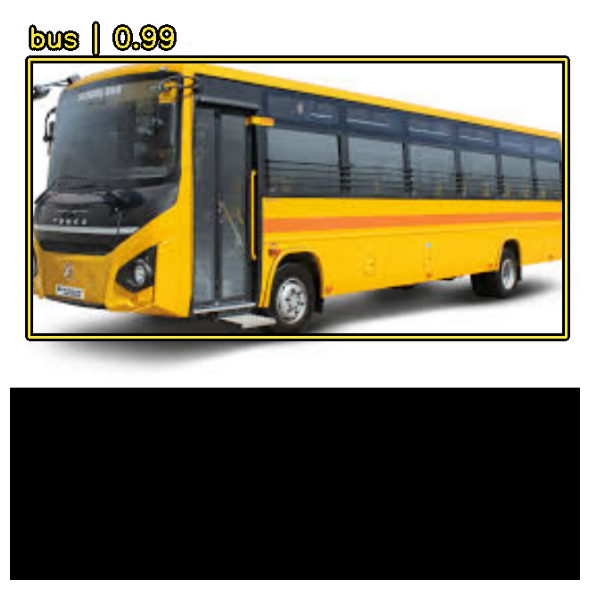


----------------------------------------
Analyzing image: Cat
----------------------------------------
Detected Objects Summary:
- cat: 98.36% confidence


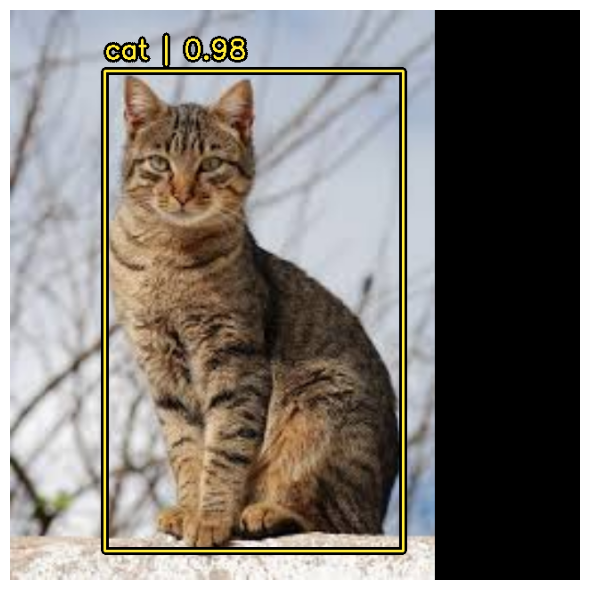


----------------------------------------
Analyzing image: Train
----------------------------------------
Detected Objects Summary:
- train: 97.26% confidence


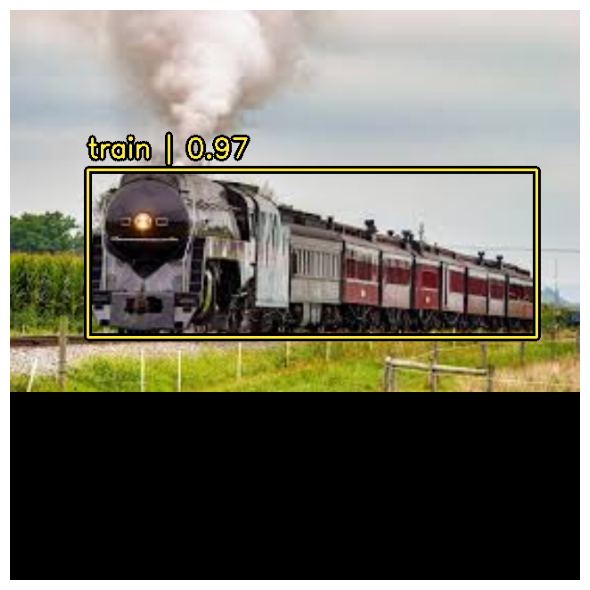


----------------------------------------
Analyzing image: Potted Plant
----------------------------------------
Detected Objects Summary:
- pottedplant: 88.70% confidence


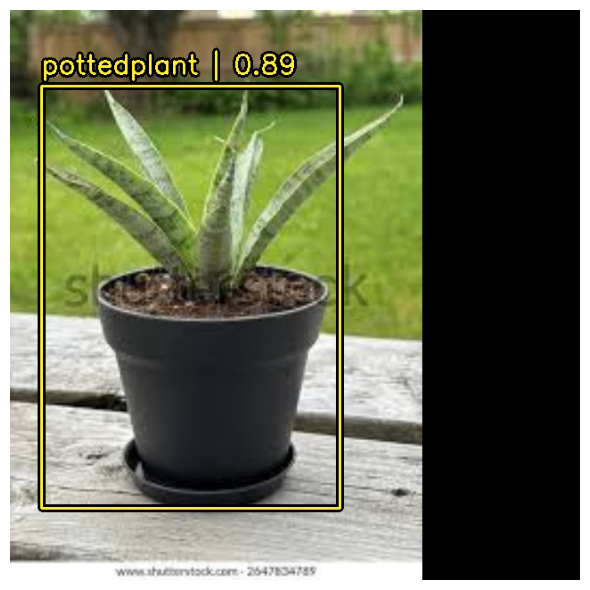

In [9]:
import keras
import keras_cv
import numpy as np
from PIL import Image

voc_classes = {
    0: "aeroplane", 1: "bicycle", 2: "bird", 3: "boat", 4: "bottle",
    5: "bus", 6: "car", 7: "cat", 8: "chair", 9: "cow",
    10: "diningtable", 11: "dog", 12: "horse", 13: "motorbike", 14: "person",
    15: "pottedplant", 16: "sheep", 17: "sofa", 18: "train", 19: "tvmonitor"
}

print("=> Loading YOLOv8 Pascal VOC model...")
yolo_model = keras_cv.models.YOLOV8Detector.from_preset(
    "yolo_v8_m_pascalvoc",
    bounding_box_format="xywh"
)

print("=> Initializing the required Resizing Layer...")
inference_resizing = keras_cv.layers.Resizing(
    640, 640, pad_to_aspect_ratio=True, bounding_box_format="xywh"
)

target_files = [
    ("Sheep", "/content/sheep.jpg"),
    ("Bus", "/content/bus.jpg"),
    ("Cat", "/content/cat.jpg"),
    ("Train", "/content/train.jpg"),
    ("Potted Plant", "/content/potted_plant.jpg")
]

for label, path in target_files:
    print(f"\n{'-'*40}\nAnalyzing image: {label}\n{'-'*40}")

    raw_image = Image.open(path).convert("RGB")
    img_array = np.array(raw_image)
    input_batch = np.expand_dims(img_array, axis=0)

    resized_batch = inference_resizing(input_batch)

    box_predictions = yolo_model.predict(resized_batch, verbose=0)

    confidences = box_predictions["confidence"][0]
    classes = box_predictions["classes"][0]

    print("Detected Objects Summary:")
    for i in range(len(confidences)):
        conf = confidences[i]
        if conf > 0:
            class_id = int(classes[i])
            object_name = voc_classes.get(class_id, "Unknown")
            print(f"- {object_name}: {conf*100:.2f}% confidence")

    keras_cv.visualization.plot_bounding_box_gallery(
        resized_batch,
        value_range=(0, 255),
        bounding_box_format="xywh",
        y_pred=box_predictions,
        class_mapping=voc_classes,
        scale=6,
        rows=1,
        cols=1,
        show=True,
    )

| Image File | Target Object | Detected Correctly? | Confidence Score | Notes (Missed/Incorrect objects) |
| :--- | :--- | :--- | :--- | :--- |
| `sheep.jpg` | Sheep | Yes | 69.97% | Detected correctly. No other objects detected. |
| `bus.jpg` | Bus | Yes | 98.58% | Detected correctly. No other objects detected. |
| `cat.jpg`| Cat | Yes | 98.36% | Detected correctly. No other objects detected. |
| `train.jpg` | Train | Yes | 97.26% | Detected correctly. No other objects detected. |
| `potted_plant.jpg`| Potted Plant | Yes | 88.70% | Detected correctly. No other objects detected. |